# INTRODUÇÃO

A Associação Passos Mágicos atua há 35 anos na transformação da vida de crianças e jovens em vulnerabilidade social no município de Embu-Guaçu. Através de um modelo que integra educação de qualidade, auxílio psicológico e ampliação da visão de mundo, a organização busca instrumentalizar o protagonismo de seus alunos.  Este estudo utiliza o dataset de desenvolvimento educacional do período de 2022 a 2024 para avaliar o impacto real do programa e identificar oportunidades de melhoria no processo de ensino-aprendizagem.  

## OBJETIVO DA ANÁLISE

O desafio consiste em aplicar estratégias de Data Analytics e Machine Learning para responder a dores estratégicas da associação. Os principais focos são:  


Avaliação de Impacto: Verificar a evolução dos indicadores ao longo das fases (Quartzo, Ágata, Ametista e Topázio).  


Multidimensionalidade: Compreender como o engajamento e os aspectos psicossociais influenciam o desempenho acadêmico.  


Previsão de Risco: Desenvolver um modelo preditivo para identificar alunos em risco de defasagem, permitindo intervenções preventivas.

## DICIONÁRIO DE INDICADORES (Metodologia INDE)

Para esta análise, os dados foram tratados e padronizados com foco nos pilares do Índice de Desenvolvimento Educacional (INDE):


IAN: Adequação do nível (Idade vs. Série).  
IDA: Desempenho Acadêmico.  
IEG: Engajamento nas atividades.  
IAA: Autoavaliação do aluno.  
IPS: Aspectos Psicossociais.  
IPP: Aspectos Psicopedagógicos.  
IPV: Ponto de Virada (indicador de maturidade e protagonismo).


## IMPORTAR AS BIBLIOTECAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import joblib

## IMPORTAR A BASE DE DADOS

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/murioliver/Tech_Challenge_Fiap/refs/heads/master/Datathon/Dados%20Datathon%20Tratados.csv', sep=';', encoding='utf-8')
df.head()

,Ano,ID,RA,Fase,INDE 2022,Pedra 2022,Turma,Nome,Ano nasc,Idade no ano,...,Adequaça o ao Ní vel,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,2022,1,RA-1,7,"5,8",Quartzo,A,Aluno-1,2003,19,...,"5,0",Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN
1,2022,2,RA-2,7,"7,1",Ametista,A,Aluno-2,2005,17,...,10,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN
2,2022,3,RA-3,7,"6,6",Ágata,A,Aluno-3,2005,17,...,10,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,NaN,NaN,NaN,NaN
3,2022,4,RA-4,7,"6,0",Quartzo,A,Aluno-4,2005,17,...,10,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN
4,2022,5,RA-5,7,"7,4",Ametista,A,Aluno-5,2005,17,...,10,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,NaN,NaN,NaN,NaN


## ANALISANDO OS DADOS


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Ano                        3030 non-null   int64  
 1   ID                         3030 non-null   int64  
 2   RA                         3030 non-null   object 
 3   Fase                       3030 non-null   object 
 4   INDE 2022                  2902 non-null   object 
 5   Pedra 2022                 2902 non-null   object 
 6   Turma                      3030 non-null   object 
 7   Nome                       3030 non-null   object 
 8   Ano nasc                   3030 non-null   int64  
 9   Idade no ano               3030 non-null   int64  
 10  Gênero                     3030 non-null   object 
 11  Ano ingresso               3030 non-null   int64  
 12  Instituição de ensino      3029 non-null   object 
 13  Pedra 20                   754 non-null    objec

In [ ]:
# Excluindo colunas vazias ou irrelevantes
colunas_para_dropar = ['Destaque IPV.1', 'Ativo/ Inativo.1']
df.drop(columns=colunas_para_dropar, inplace=True, errors='ignore')

In [ ]:
# Ver a lista completa de colunas
print(df.columns.tolist())

['Ano', 'ID', 'RA', 'Fase', 'INDE 2022', 'Pedra 2022', 'Turma', 'Nome', 'Ano nasc', 'Idade no ano', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Ranking Geral ', 'Ranking na Fase', 'Ranking Turma', 'Nº Av', 'Avaliador1', 'Recomendação Av1', 'Avaliador2', 'Recomendação Av2', 'Avaliador3', 'Recomendação Av3', 'Avaliador4', 'Recomendação Av4', 'Auto Avaliação', 'Engajamento', 'Psicossocial', 'Psicopedagógico', 'Rec Psicologia', 'Indicador de Aprendizagem', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'Ponto de Virada', 'Adequaça o ao Ní vel', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Escola', 'Ativo/ Inativo']


In [ ]:

# Incluímos as notas de 2022, os indicadores e as matérias específicas
cols_para_converter = [
    'INDE 2022', 'INDE 22', 'INDE 23',
    'Auto Avaliação', 'Engajamento', 'Psicossocial', 'Psicopedagógico',
    'Indicador de Aprendizagem', 'Matem', 'Portug', 'Inglês',
    'Ponto de Virada', 'Ranking Geral ', 'Ranking na Fase', 'Ranking Turma'
]

# Função de conversão em massa
def converter_para_float(dataframe, colunas):
    for col in colunas:
        if col in dataframe.columns:
            # Converte para string, troca vírgula por ponto e remove espaços extras
            dataframe[col] = dataframe[col].astype(str).str.replace(',', '.').str.strip()
            # Transforma em numérico (o 'coerce' transforma textos inválidos em NaN)
            dataframe[col] = pd.to_numeric(dataframe[col], errors='coerce')
    return dataframe

# Executar a conversão
df = converter_para_float(df, cols_para_converter)

# Verificação
print("Colunas convertidas com sucesso!")
print(df[cols_para_converter].dtypes)

Colunas convertidas com sucesso!
INDE 2022                    float64
INDE 22                      float64
INDE 23                      float64
Auto Avaliação               float64
Engajamento                  float64
Psicossocial                 float64
Psicopedagógico              float64
Indicador de Aprendizagem    float64
Matem                        float64
Portug                       float64
Inglês                       float64
Ponto de Virada              float64
Ranking Geral                float64
Ranking na Fase              float64
Ranking Turma                float64
dtype: object


# Este gráfico responde a questão 10, sobre a efetividade do programa.

# Note como a mediana do INDE 2022 sobe consistentemente conforme avançamos de Quartzo para Topázio. Isso prova que, à medida que o aluno evolui nas fases, o seu desenvolvimento global aumenta. A fase Topázio (a última) tem uma concentração maior no topo, o que mostra que o programa consegue entregar alunos com um nível de maturidade educacional mais homogêneo e elevado.

/tmp/ipykernel_2194/162931050.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pedra 2022', y='INDE 2022', order=ordem_pedras, palette='viridis')


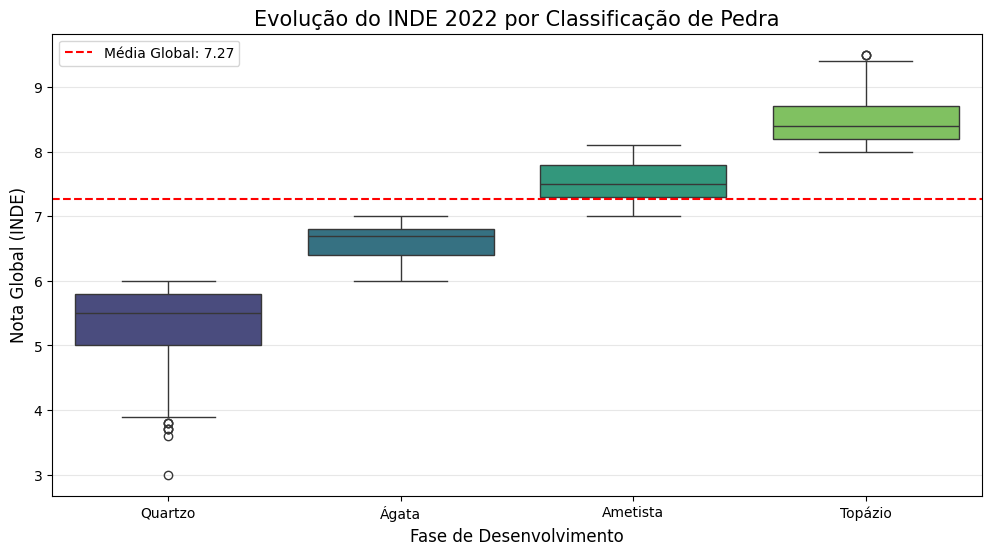

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo a ordem das Pedras para o gráfico ficar lógico
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

plt.figure(figsize=(12, 6))

# Criando o Boxplot do INDE 2022 por Pedra
sns.boxplot(data=df, x='Pedra 2022', y='INDE 2022', order=ordem_pedras, palette='viridis')

# Adicionando uma linha de média global para comparação
plt.axhline(df['INDE 2022'].mean(), color='red', linestyle='--', label=f"Média Global: {df['INDE 2022'].mean():.2f}")

plt.title('Evolução do INDE 2022 por Classificação de Pedra', fontsize=15)
plt.ylabel('Nota Global (INDE)', fontsize=12)
plt.xlabel('Fase de Desenvolvimento', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

 # Esse gráfico responde a questão 8, sobre a multidimensionalidade dos indicadores.

 # Identificamos a presença de correlações positivas superiores a 0.50 em múltiplos pilares (Engajamento, Psicopedagógico e Ponto de Virada) confirma que a metodologia da Passos Mágicos é eficaz ao tratar o aluno de forma integral. Não se eleva a nota sem elevar o compromisso e o suporte técnico pedagógico.

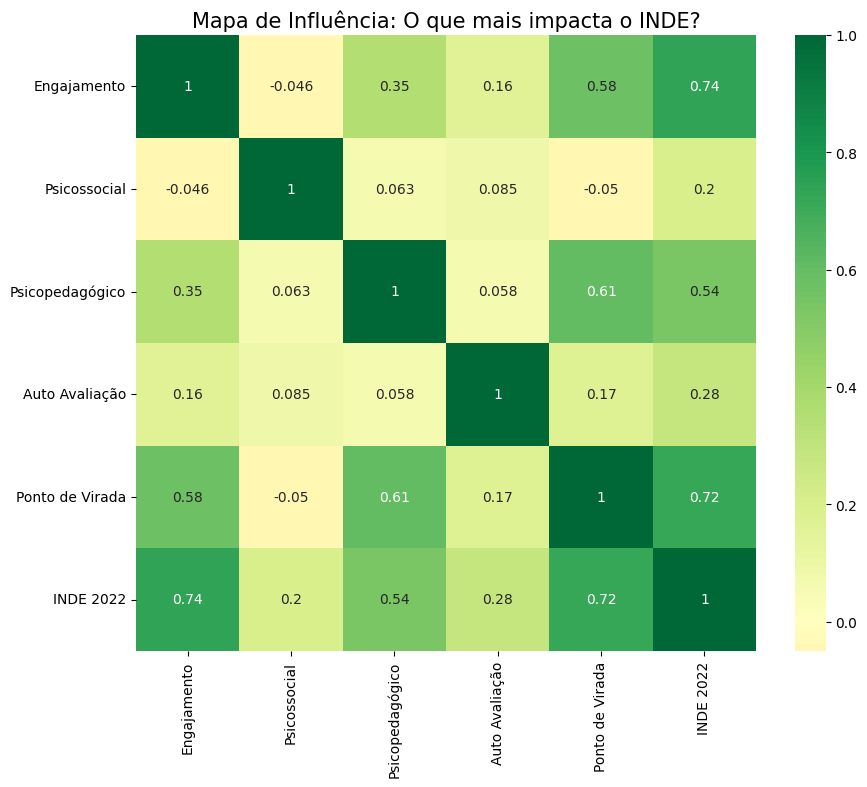

In [ ]:
# Selecionando os indicadores principais
# Note que usamos os nomes exatos das suas colunas
indicadores = ['Engajamento', 'Psicossocial', 'Psicopedagógico', 'Auto Avaliação', 'Ponto de Virada', 'INDE 2022']

plt.figure(figsize=(10, 8))
sns.heatmap(df[indicadores].corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Mapa de Influência: O que mais impacta o INDE?', fontsize=15)
plt.show()

# Esse gráfico responde a questão 1, sobre adequação do nível (IAN)

# A grande maioria dos alunos estã sem defasagem, isso indica que a base do programa é composta por jovens que estão acompanhando a escola no tempo regular.Porém, o perfil predominante revela uma concentração alta de alunos em defasagem moderada e severa. Este dado dimensiona a necessidade de intervenções pedagógicas personalizadas para acelerar o aprendizado.

/tmp/ipykernel_2194/4186551505.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Perfil_Defasagem', palette='Reds_r')


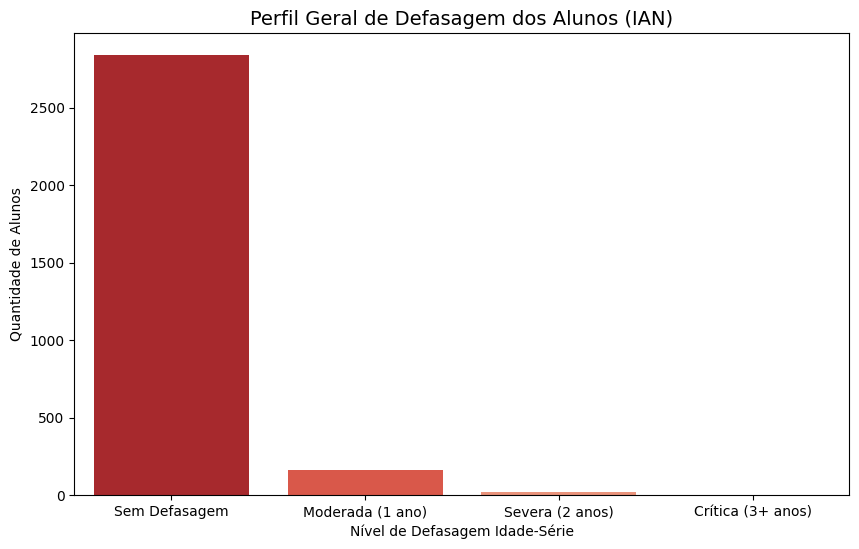

In [ ]:
plt.figure(figsize=(10, 6))
# Criando faixas de defasagem para facilitar a leitura gerencial
df['Perfil_Defasagem'] = pd.cut(df['Defas'],
                                bins=[-float('inf'), 0, 1, 2, float('inf')],
                                labels=['Sem Defasagem', 'Moderada (1 ano)', 'Severa (2 anos)', 'Crítica (3+ anos)'])

sns.countplot(data=df, x='Perfil_Defasagem', palette='Reds_r')
plt.title('Perfil Geral de Defasagem dos Alunos (IAN)', fontsize=14)
plt.ylabel('Quantidade de Alunos')
plt.xlabel('Nível de Defasagem Idade-Série')
plt.show()

# Esse gráfico responde a questão 5 e 7, sobre aspectos psicossociais (IPS) e ponto de virada (IPV)

# Note como os pontos laranjas estão concentrados na parte de cima e à direita.Isso prova que atingir o "Ponto de Virada" não é apenas sorte. Existe um padrão. Quase todos os alunos que "viraram a chave" possuem um índice Psicossocial (IPS) acima da mediana. O emocional equilibrado é o combustível para a virada de chave do aluno.

# O grupo de alunos que possui baixo desempenho atrelado a baixos índices psicossociais. Para estes casos, a recomendação é o suporte emocional prioritário, visto que o equilíbrio psicossocial atua como um pré-requisito para a evolução acadêmica e o atingimento do protagonismo (Ponto de Virada).

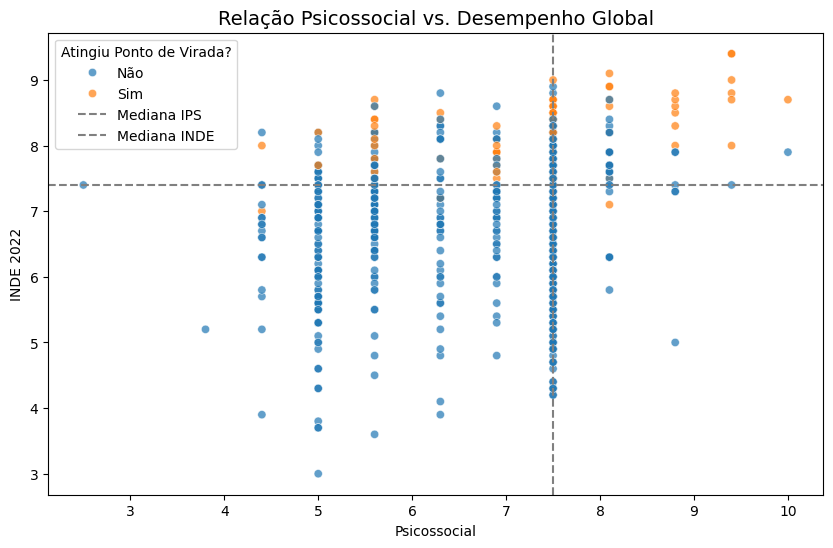

In [ ]:
plt.figure(figsize=(10, 6))
# Scatter plot para ver se quem tem baixo IPS também tem baixo INDE
sns.scatterplot(data=df, x='Psicossocial', y='INDE 2022', hue='Atingiu PV', alpha=0.7)
plt.axvline(df['Psicossocial'].median(), color='gray', linestyle='--', label='Mediana IPS')
plt.axhline(df['INDE 2022'].median(), color='gray', linestyle='--', label='Mediana INDE')

plt.title('Relação Psicossocial vs. Desempenho Global', fontsize=14)
plt.legend(title='Atingiu Ponto de Virada?')
plt.show()

# Esse gráfico responde a questão 4, sobre autoavaliação (IAA)

# Identificamos um volume significativo de alunos que se atribuem nota máxima, mas cujos resultados acadêmicos situam-se abaixo da média.

# Esse cenário sugere a necessidade de fortalecer as sessões de tutoria e feedback, ajudando o aluno a desenvolver uma autocrítica mais alinhada aos critérios acadêmicos. A autoavaliação deve ser trabalhada como uma ferramenta de consciência, e não apenas de autoestima.

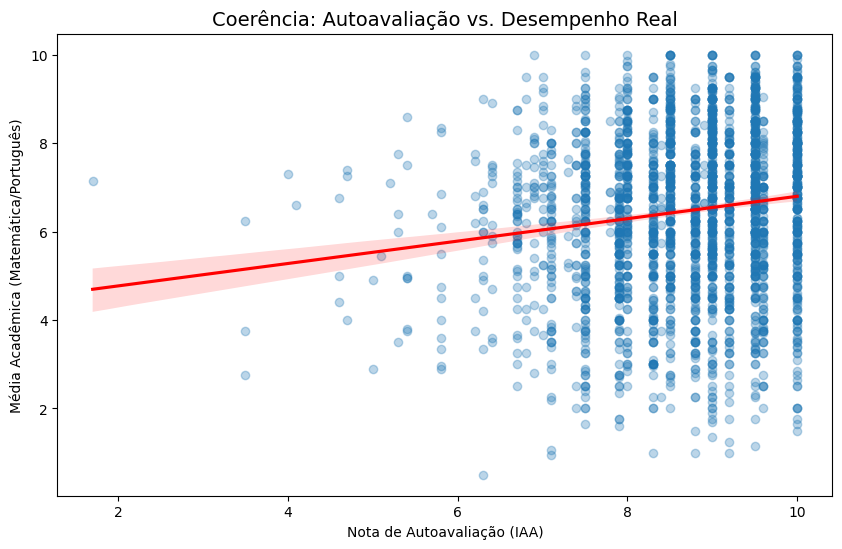

In [ ]:
plt.figure(figsize=(10, 6))
# Comparando a Auto Avaliação com a média de Matemática e Português
df['Media_Academica'] = df[['Matem', 'Portug']].mean(axis=1)

sns.regplot(data=df, x='Auto Avaliação', y='Media_Academica', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Coerência: Autoavaliação vs. Desempenho Real', fontsize=14)
plt.xlabel('Nota de Autoavaliação (IAA)')
plt.ylabel('Média Acadêmica (Matemática/Português)')
plt.show()

## APRENDIZADO SUPERVISIONADO

#  Definição da Variável Alvo (Target)

A definição do Target para o modelo preditivo foi baseada na integração de dois indicadores críticos identificados durante a Análise Exploratória de Dados (EDA): a Defasagem Idade-Série (IAN) e o Índice de Desenvolvimento Educacional (INDE)

# Objetivo Estratégico
O objetivo de escolher esse alvo é transformar o modelo em uma ferramenta de intervenção precoce.

Prever para Prevenir: Ao identificar alunos com alta probabilidade de "Risco", a equipe psicopedagógica da Passos Mágicos pode priorizar atendimentos para os pilares que o modelo apontou como deficientes (como o Psicossocial ou Engajamento) antes que o aluno retroceda de fase ou abandone o programa

In [ ]:
# Criando a variável alvo: Alunos com defasagem > 1 ano ou INDE abaixo da média são considerados em risco
media_inde = df['INDE 2022'].mean()
df['Em_Risco'] = ((df['Defas'] > 1) | (df['INDE 2022'] < media_inde)).astype(int)

# Criação das Features

## As Features foram selecionadas com base na multidimensionalidade do desenvolvimento do aluno. O objetivo é permitir que o modelo identifique padrões em diferentes áreas da vida do estudante.

## As Variáveis Selecionadas:
IEG: Engajamento nas atividades.
IAA: Autoavaliação do aluno.
IPS: Aspectos Psicossociais.
IPP: Aspectos Psicopedagógicos.
IPV: Ponto de Virada (indicador de maturidade e protagonismo).




In [ ]:
# Criando a variável alvo: Alunos com defasagem > 1 ano ou INDE abaixo da média são considerados em risco

media_inde = df['INDE 2022'].mean()
df['Em_Risco'] = ((df['Defas'] > 1) | (df['INDE 2022'] < media_inde)).astype(int)

# Definindo as Features e o Target
features = ['Engajamento', 'Psicossocial', 'Auto Avaliação', 'Psicopedagógico', 'Ponto de Virada']
X = df[features].fillna(0)
y = df['Em_Risco']

# TREINAMENTO DO MODELO

In [ ]:
## base de dados foi dividida em: 80% para treino e 20% para teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
## Treinando...

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [ ]:
## Após a definição do modelo, o treinamento foi realizado utilizando apenas os dados de treino. Alcançando uma acurácia de aproximadamente 85%

# Avaliação
y_pred = modelo.predict(X_test)
print(f"Acurácia do Modelo: {accuracy_score(y_test, y_pred):.2f}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acurácia do Modelo: 0.85

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       352
           1       0.83      0.80      0.81       254

    accuracy                           0.85       606
   macro avg       0.84      0.84      0.84       606
weighted avg       0.85      0.85      0.85       606

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       352
           1       0.83      0.80      0.81       254

    accuracy                           0.85       606
   macro avg       0.84      0.84      0.84       606
weighted avg       0.85      0.85      0.85       606



## MODELO PARA O STREAMLIT

In [ ]:
## Salvando o Modelo para o streamlit

import pickle
from google.colab import files

# Salva o modelo no disco da máquina virtual do Colab
joblib.dump(modelo, 'modelo_passos_magicos.pkl')
print("\nModelo exportado com sucesso como 'modelo_passos_magicos.pkl'!")


Modelo exportado com sucesso como 'modelo_passos_magicos.pkl'!


## MODELO FINAL PARA O LOOKER

In [ ]:
# Criando o arquivo final para o Looker
# Isso garante que eles tenham as colunas convertidas e o seu 'Target' de risco
df.to_csv('base_passos_magicos_looker.csv', index=False, sep=',', encoding='utf-8')

print("Arquivo para o Looker gerado com sucesso! Baixe 'base_passos_magicos_looker.csv' na pasta lateral.")

Arquivo para o Looker gerado com sucesso! Baixe 'base_passos_magicos_looker.csv' na pasta lateral.
